.# Лабораторная работа №1: Первичное исследование данных

## 1. Постановка задачи

### Описание датасета
Набор данных содержит подробную информацию об около 23 тысячах автомобилей в прокатах по РФ. Датасет охватывает такие параметры как марка, модель мощность, класс, тип кузова и многое другое


### Условный заказчик:
Автомобильные дилеры, сервисы проката автомобилей.


### Возможные задачи ИАД
1. Анализ рыночного предложения и ценообразования: Исследование зависимости цены автомобиля от технических характеристик (мощность, объем двигателя, привод, тип коробки передач), года выпуска и марки. Построение моделей предсказания рыночной стоимости.
2. Сегментация автомобильного парка и анализ потребительских предпочтений: Кластеризация автомобилей по техническим параметрам и цене для выявления основных рыночных сегментов. Анализ популярности различных типов кузова (SUV, седан, минивэн), марок и классов автомобилей в разных ценовых категориях.
3. Оптимизация автопарка для прокатных сервисов: Анализ взаимосвязи характеристик автомобилей (расход топлива, клиренс, объем багажника) и их потенциальной востребованности в прокате. Определение оптимального состава автопарка по классам и характеристикам для максимизации прибыли.

## 2. Паспорт датасета

### Загрузка данных

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/cars_dataset.csv', low_memory=False)  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

df[['Seats', 'Doors', 'Year', 'Valves_per_cylinder', 'Cylinders', 'Maximum_speed']] = df[['Seats', 'Doors', 'Year', 'Valves_per_cylinder', 'Cylinders', 'Maximum_speed']].astype('int')
df[['Box', 'Drive_unit', 'Country', 'Drive', 'Boost_type', 'Cylinder_location', 'Front_Suspension_type', 'Car_class', 'Fuel', 'Engine_Location']] = df[['Box', 'Drive_unit', 'Country', 'Drive', 'Boost_type', 'Cylinder_location', 'Front_Suspension_type', 'Car_class', 'Fuel', 'Engine_Location']].astype('category')

df.head()

Размер датасета: 22702 строк, 55 столбцов


,Unnamed: 0,mark,Box,Drive_unit,Seats,Doors,Country,Engine,Volume,Color,...,Consumption,Engine_Power,Restyling,Release_start_series,End_Serial,Trunk_volume_max,Trunk_volume_min,Expense_city,Expense_track,Consumption_average
0,0,Mercedes-Benz,automatic,full,5,5,German,diesel,2.9,black,...,9.8,NaN,0.0,2018.0,2020.0,667.0,1941.0,11.5,9.2,9.8
1,1,Mercedes-Benz,automatic,full,5,5,German,diesel,2.9,green,...,9.6,NaN,0.0,2018.0,2020.0,667.0,1941.0,10.8,8.9,9.6
2,2,Mercedes-Benz,automatic,full,5,5,German,gasoline,4.0,black,...,12.1,direct injection (direct),0.0,2018.0,2020.0,667.0,1941.0,14.1,10.8,12.1
3,3,Mercedes-Benz,automatic,full,5,5,German,gasoline,4.0,black,...,12.1,direct injection (direct),0.0,2018.0,2020.0,667.0,1941.0,14.1,10.8,12.1
4,4,Mercedes-Benz,automatic,full,5,5,German,gasoline,4.0,gray,...,12.1,direct injection (direct),0.0,2018.0,2020.0,667.0,1941.0,14.1,10.8,12.1


### Структура данных

In [11]:
# Информация о столбцах и типах
df.info()

# Статистика по числовым признакам
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 22702 entries, 0 to 22701
Data columns (total 55 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Unnamed: 0                           22702 non-null  int64   
 1   mark                                 22702 non-null  str     
 2   Box                                  22702 non-null  category
 3   Drive_unit                           22702 non-null  category
 4   Seats                                22702 non-null  int64   
 5   Doors                                22702 non-null  int64   
 6   Country                              22702 non-null  category
 7   Engine                               22702 non-null  str     
 8   Volume                               22702 non-null  float64 
 9   Color                                22702 non-null  str     
 10  Mileage                              22702 non-null  float64 
 11  Price                     

,Unnamed: 0,Seats,Doors,Volume,Mileage,Price,Year,Engine_volume,Width,Diameter_cylinder_and_stroke_piston,...,Compression_ratio,Consumption,Restyling,Release_start_series,End_Serial,Trunk_volume_max,Trunk_volume_min,Expense_city,Expense_track,Consumption_average
count,22702.000000,22702.00000,22702.000000,22702.000000,22702.000000,2.270200e+04,22702.000000,22702.000000,22702.000000,22702.000000,...,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000,22702.000000
mean,18318.491499,5.01251,4.418774,2.334922,136649.516210,1.353936e+06,2009.204563,2337.199911,1813.402914,73.521181,...,11.149437,7.154378,0.339794,2006.610078,2011.682451,472.146991,853.949520,8.730698,5.339745,6.605114
std,10561.840988,0.76348,0.810206,1.049301,101154.431413,2.493866e+06,9.116164,1037.923141,98.746721,27.948965,...,2.438177,3.640578,0.473650,10.340075,8.284589,321.706597,937.394434,5.345248,3.120095,3.929169
min,0.000000,1.00000,0.000000,0.000000,0.000000,2.000000e+04,1927.000000,599.000000,1275.000000,0.000000,...,5.800000,0.000000,0.000000,1927.000000,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9038.750000,5.00000,4.000000,1.600000,62322.000000,3.740750e+05,2006.000000,1598.000000,1755.000000,77.000000,...,10.000000,6.100000,0.000000,2003.000000,2008.000000,352.000000,0.000000,6.900000,4.700000,5.600000
50%,18573.500000,5.00000,5.000000,2.000000,125000.000000,6.800000e+05,2011.000000,1997.000000,1810.000000,82.000000,...,10.500000,7.400000,0.000000,2008.000000,2013.000000,456.000000,815.000000,9.400000,5.800000,7.200000
75%,27572.750000,5.00000,5.000000,2.700000,191786.000000,1.420000e+06,2015.000000,2693.000000,1875.000000,86.200000,...,11.149437,9.100000,1.000000,2013.000000,2018.000000,530.000000,1547.000000,11.700000,7.100000,8.800000
max,36664.000000,9.00000,5.000000,8.100000,1000000.000000,1.300000e+08,2020.000000,8128.000000,2360.000000,108.000000,...,23.000000,28.200000,1.000000,2020.000000,2020.000000,5800.000000,9300.000000,36.200000,21.100000,28.200000


## 3. Аудит качества данных

### 3.1. Пропуски

In [12]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

,Пропуски,Доля (%)
Engine_Power,3562,15.69
Wheel_size,1540,6.78
Engine_Location,1357,5.98
Fuel,419,1.85
Boost_type,283,1.25
Cylinder_location,247,1.09
Car_class,221,0.97
Drive,191,0.84
Front_Suspension_type,191,0.84
Front_brakes,191,0.84


### 3.2. Дубликаты

In [29]:
duplicates = df.duplicated().sum()
print(f'Полных дубликатов строк: {duplicates}')
df_copy = df.copy()
df_copy.drop("Unnamed: 0", axis=1)
duplicates_without_index = df_copy.duplicated().sum()
print(f'Полных дубликатов строк: {duplicates_without_index}')

Полных дубликатов строк: 0
Полных дубликатов строк: 0


### 3.3. Выбросы (пример для одного признака)

Выбросов по методу IQR: 1644


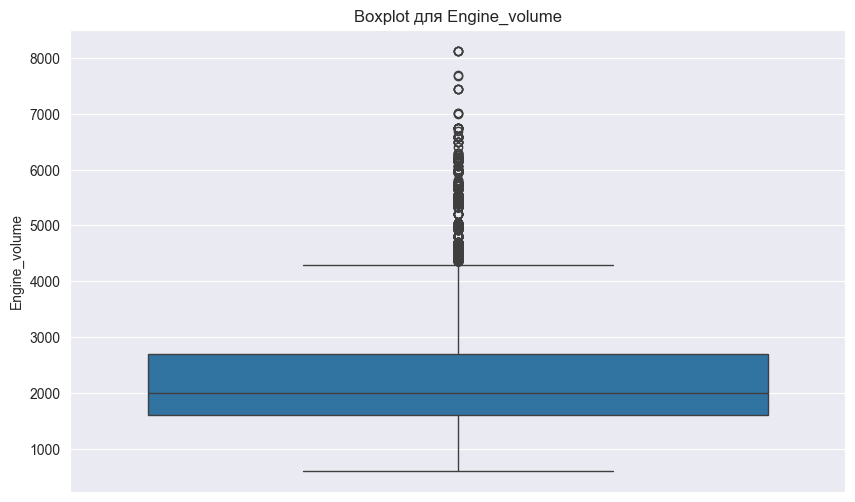

In [14]:
# Замените 'your_numeric_column' на реальное название столбца
column = 'Engine_volume'
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')

# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column}')
plt.show()

## 4. Разведочный анализ (EDA)

### 4.1. Распределение числового признака

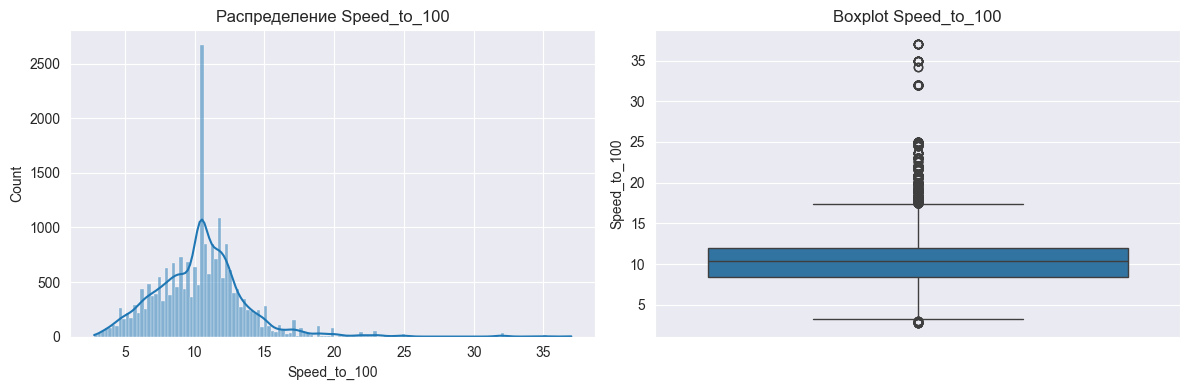

In [15]:
# Замените на реальный признак
numeric_col = 'Speed_to_100'

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_col], kde=True)
plt.title(f'Распределение {numeric_col}')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[numeric_col])
plt.title(f'Boxplot {numeric_col}')
plt.tight_layout()
plt.show()

### 4.2. Анализ категориального признака

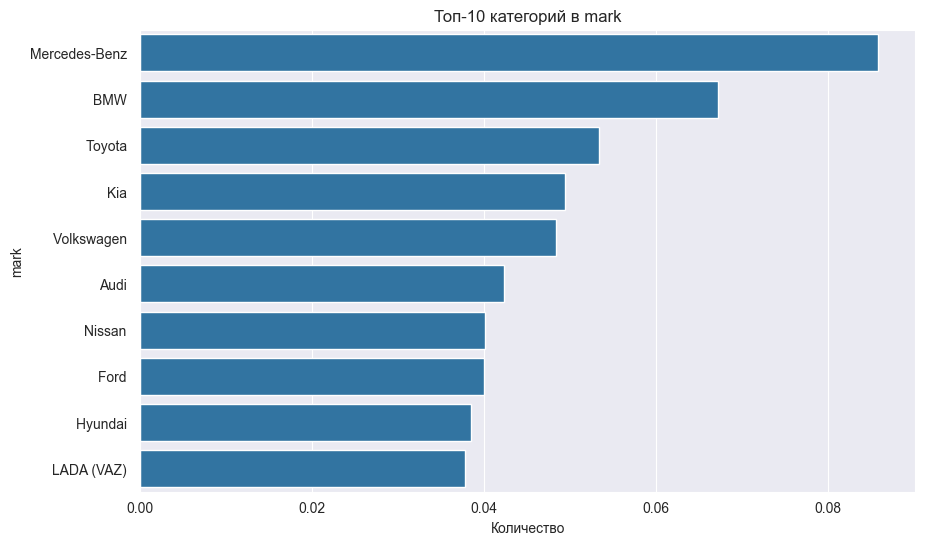

In [62]:
# Замените на реальный категориальный признак
cat_col = 'mark'

plt.figure(figsize=(10, 6))
top_categories = df.value_counts(cat_col, normalize=True).head(10)
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title(f'Топ-10 категорий в {cat_col}')
plt.xlabel('Количество')
plt.show()

## 5. Выводы

Детали в файле `report/quality_report.md`